# Improved 10-Year Bond Yield Prediction (Stacked LSTM)

## Overview
This notebook implements an **improved** 3-layer stacked LSTM model to predict the **future 5-day changes** of the 10-year Chinese government bond yield.

## Improvements
1. **Strict Data Splitting**: The scaler is fitted **only** on the training set to prevent data leakage.
2. **Regularization**: Increased Dropout and added Learning Rate Scheduler to combat overfitting.
3. **Architecture**: 3-layer LSTM (128, 64, 32) + 2 Dense Layers (32, 5).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

%matplotlib inline

2025-12-17 03:55:25.955729: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 03:55:26.690172: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2025-12-17 03:55:31.080626: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
def load_data(filepath):
    try:
        df = pd.read_csv(filepath, skiprows=8, header=None, encoding='gbk', names=['Date', 'Yield'])
    except Exception as e:
        print(f"Error reading csv: {e}")
        return None

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df = df.sort_values('Date')
    df['Yield'] = pd.to_numeric(df['Yield'], errors='coerce')
    df = df.dropna(subset=['Yield'])
    return df.reset_index(drop=True)

filepath = '中债国债到期收益率_10年.csv'
df = load_data(filepath)
print(f"Loaded {len(df)} rows.")

Loaded 1238 rows.


In [3]:
# 1. First Order Difference
df['Yield_Diff'] = df['Yield'].diff()
df_diff = df.dropna().reset_index(drop=True)

# 2. Determine Split Index for Scaling
# We need to respect the time split order: Train -> Val -> Test
# Total Samples ~ 1172. 
# Window=60, Horizon=5.
# Total valid data points for sequences = N - Window - Horizon + 1
N = len(df_diff)
window_size = 60
horizon = 5
num_samples = N - window_size - horizon + 1

# Calculate split points based on sample count
train_val_split_idx = int(num_samples * 0.8)
train_split_idx = int(train_val_split_idx * 0.9)

# The training data ends at the data point corresponding to the last input of the last training sample.
# Sample i uses indices [i : i+window].
# Last training sample index is (train_split_idx - 1).
# So it uses data up to (train_split_idx - 1 + window).
# To be safe and strict, we fit scaler on the raw data that covers ONLY the training input samples.
scaler_fit_end_idx = train_split_idx + window_size

print(f"Total Data Points: {N}")
print(f"Total Samples: {num_samples}")
print(f"Train Samples: {train_split_idx}")
print(f"Fitting scaler on first {scaler_fit_end_idx} data points.")

# 3. Normalize (Fit on Train ONLY)
scaler = MinMaxScaler(feature_range=(-1, 1))
train_data = df_diff[['Yield_Diff']].iloc[:scaler_fit_end_idx]
scaler.fit(train_data)

# Transform entire dataset
data_scaled = scaler.transform(df_diff[['Yield_Diff']])

# 4. Create Sequences
X, y = [], []
for i in range(num_samples):
    x_seq = data_scaled[i : i + window_size]
    y_seq = data_scaled[i + window_size : i + window_size + horizon]
    X.append(x_seq)
    y.append(y_seq)

X = np.array(X)
y = np.array(y)
y = y.reshape(y.shape[0], horizon)

print(f"X shape: {X.shape}, y shape: {y.shape}")

Total Data Points: 1237
Total Samples: 1173
Train Samples: 844
Fitting scaler on first 904 data points.
X shape: (1173, 60, 1), y shape: (1173, 5)


In [4]:
X_train_val = X[:train_val_split_idx]
y_train_val = y[:train_val_split_idx]

X_test = X[train_val_split_idx:]
y_test = y[train_val_split_idx:]

X_train = X_train_val[:train_split_idx]
y_train = y_train_val[:train_split_idx]

X_val = X_train_val[train_split_idx:]
y_val = y_train_val[train_split_idx:]

print(f"Train Set: {X_train.shape}")
print(f"Val Set:   {X_val.shape}")
print(f"Test Set:  {X_test.shape}")

Train Set: (844, 60, 1)
Val Set:   (94, 60, 1)
Test Set:  (235, 60, 1)


In [5]:
def build_improved_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    # Layer 1
    model.add(LSTM(128, return_sequences=True))
    model.add(Dropout(0.3))  # Increased Dropout
    
    # Layer 2
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.3))
    
    # Layer 3
    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.3))
    
    # Dense Layers
    model.add(Dense(32, activation='relu'))
    model.add(Dense(5))
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

model = build_improved_model((X_train.shape[1], X_train.shape[2]))
model.summary()

2025-12-17 03:55:33.630877: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,605 (506.27 KB)

 Trainable params: 129,605 (506.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


 1/27 ━━━━━━━━━━━━━━━━━━━━ 2:45 6s/step - loss: 0.0693 - mae: 0.2033

 2/27 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0643 - mae: 0.1961

 3/27 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0623 - mae: 0.1925

 4/27 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0604 - mae: 0.1893

...

24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0409 - mae: 0.1495

25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0408 - mae: 0.1494

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0408 - mae: 0.1492

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0407 - mae: 0.1491

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0395 - mae: 0.1457 - val_loss: 0.0869 - val_mae: 0.2022 - learning_rate: 6.2500e-05


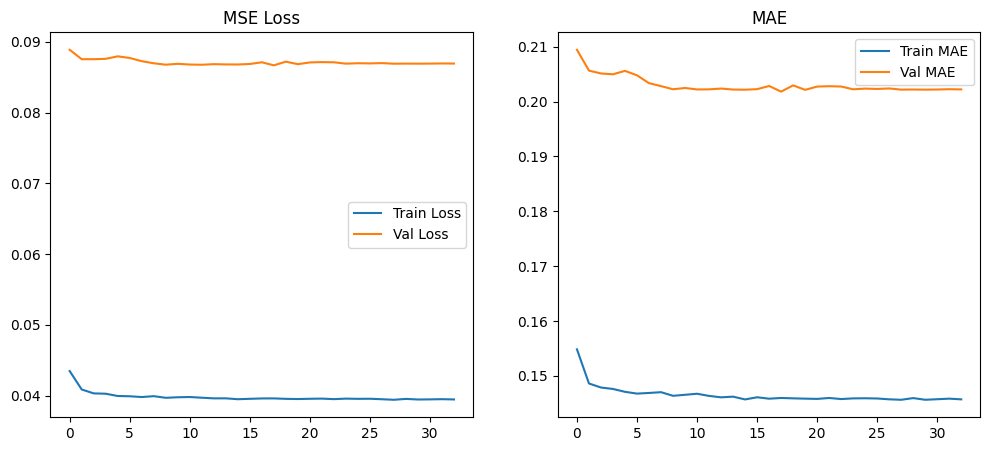

In [6]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, # Increased epochs
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# Plot History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MSE Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE')
plt.legend()
plt.show()

In [7]:
# Predict
y_pred_scaled = model.predict(X_test)

# Inverse Transform
# Reshape to (N, 1) for inverse_transform, then reshape back
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_inv = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)

# Metrics
mse_real = mean_squared_error(y_test_inv, y_pred_inv)
mae_real = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"Test MSE (Real Scale): {mse_real:.6f}")
print(f"Test MAE (Real Scale): {mae_real:.6f}")

# Calculate metrics for each day of the horizon
for i in range(5):
    mae_day = mean_absolute_error(y_test_inv[:, i], y_pred_inv[:, i])
    print(f"Day {i+1} Horizon MAE: {mae_day:.6f}")

1/8 ━━━━━━━━━━━━━━━━━━━━ 3s 434ms/step

3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step


Test MSE (Real Scale): 0.000392
Test MAE (Real Scale): 0.013804
Day 1 Horizon MAE: 0.014048
Day 2 Horizon MAE: 0.013957
Day 3 Horizon MAE: 0.013790
Day 4 Horizon MAE: 0.013588
Day 5 Horizon MAE: 0.013637


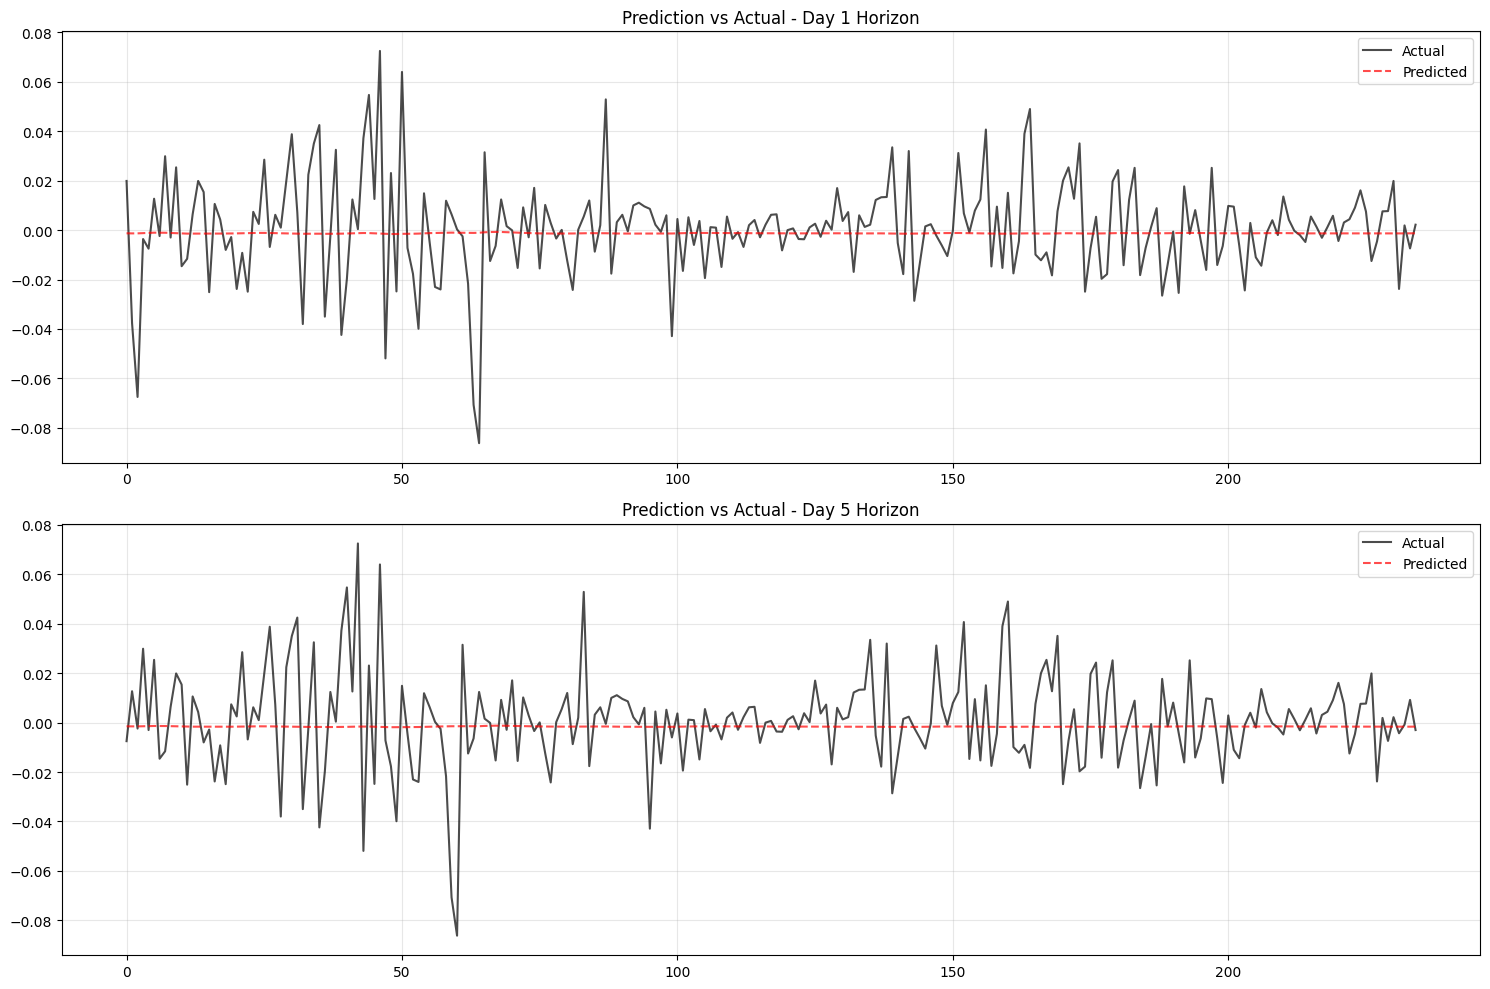

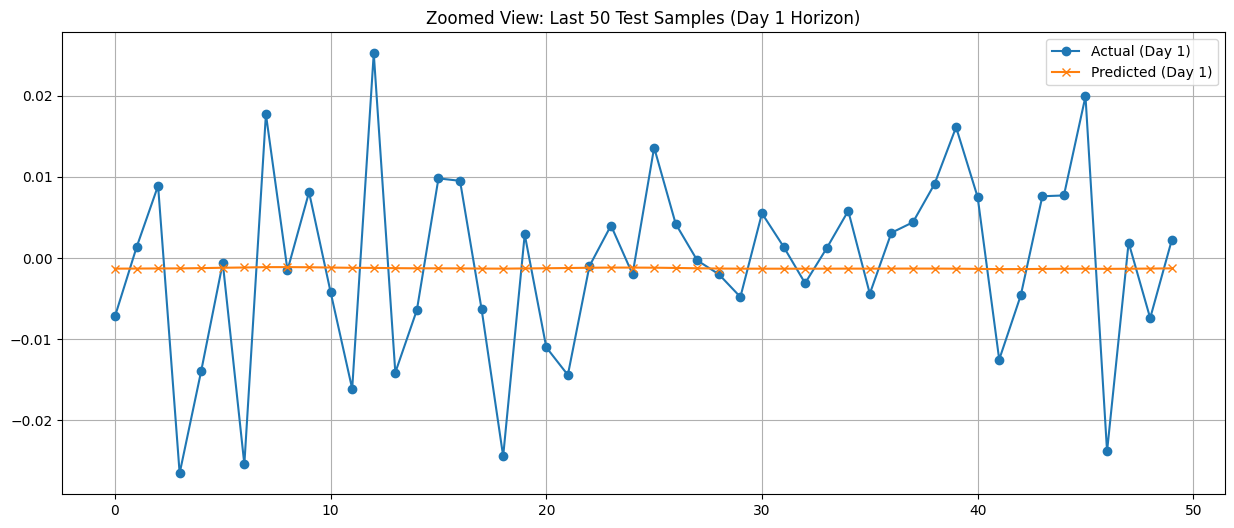

In [8]:
# Visualization
days_to_plot = [0, 4] # Day 1 and Day 5
plt.figure(figsize=(15, 10))

for idx, day_idx in enumerate(days_to_plot):
    plt.subplot(2, 1, idx+1)
    plt.plot(y_test_inv[:, day_idx], label='Actual', color='black', alpha=0.7)
    plt.plot(y_pred_inv[:, day_idx], label='Predicted', color='red', alpha=0.7, linestyle='--')
    plt.title(f'Prediction vs Actual - Day {day_idx+1} Horizon')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zoom in on last 50 days
plt.figure(figsize=(15, 6))
plt.plot(y_test_inv[-50:, 0], label='Actual (Day 1)', marker='o')
plt.plot(y_pred_inv[-50:, 0], label='Predicted (Day 1)', marker='x')
plt.title('Zoomed View: Last 50 Test Samples (Day 1 Horizon)')
plt.legend()
plt.grid(True)
plt.show()